# NB3: Psychometrics as Predictors
- **Question:** Do Big Five personality traits and non-verbal IQ predict annotation accuracy and reliance on AI?
- **Primary GT:** Platinum Consensus
- **KL1 Strategy:** Exclude (Strategy A)
- **Hypothesis:** Higher neuroticism predicts higher over-reliance on AI feedback, and baseline accuracy is modulated by IQ and conscientiousness.
- **Data Note:** The analysis is strictly performed on the **N=51 completer cohort**. Dropouts who did not complete the full study are excluded to ensure data integrity.
- **Data Note:** This notebook uses the finalized **N=51 completer cohort**. All non-completers are excluded.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pingouin as pg
import warnings
import sys, os; sys.path.append(os.path.abspath(".")); sys.path.append(os.path.abspath("..")); import helpers

warnings.filterwarnings("ignore")

    # 1. Load Data (Strictly N=51 completers)
df = helpers.load_data("exclude", filter_completers=True, filter_psychometrics=True)
df["human_correct_plat_int"] = df["human_correct_plat"].astype(int)
df["over_reliance_int"] = df["over_reliance"].astype(int)
df["human_correct_orig_int"] = df["human_correct_original"].astype(int)

df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

b5_cols = ["big5_open_mindedness", "big5_conscientiousness", "big5_extraversion", "big5_agreeableness", "big5_neuroticism", "iq_score"]
facet_cols = [c for c in df_part.columns if c.startswith("facet_")]

print(f"Setup Complete. N={len(df_part)} participants loaded.")


Data Loading: 51 participants selected (from 68 initial).
Setup Complete. N=51 participants loaded.


## Section 1: Descriptive Psychometrics

--- Descriptive Psychometrics ---
       big5_open_mindedness  big5_conscientiousness  big5_extraversion  \
count             51.000000               51.000000          51.000000   
mean               3.774118                3.383725           3.413529   
std                0.627905                0.721642           0.704681   
min                2.500000                1.920000           2.080000   
25%                3.330000                2.830000           2.835000   
50%                3.670000                3.330000           3.500000   
75%                4.210000                4.040000           3.920000   
max                4.920000                4.500000           5.000000   

       big5_agreeableness  big5_neuroticism   iq_score  
count           51.000000         51.000000  51.000000  
mean             3.653725          2.979412   1.117647  
std              0.512144          0.801105   1.632753  
min              2.580000          1.420000   0.000000  
25%           

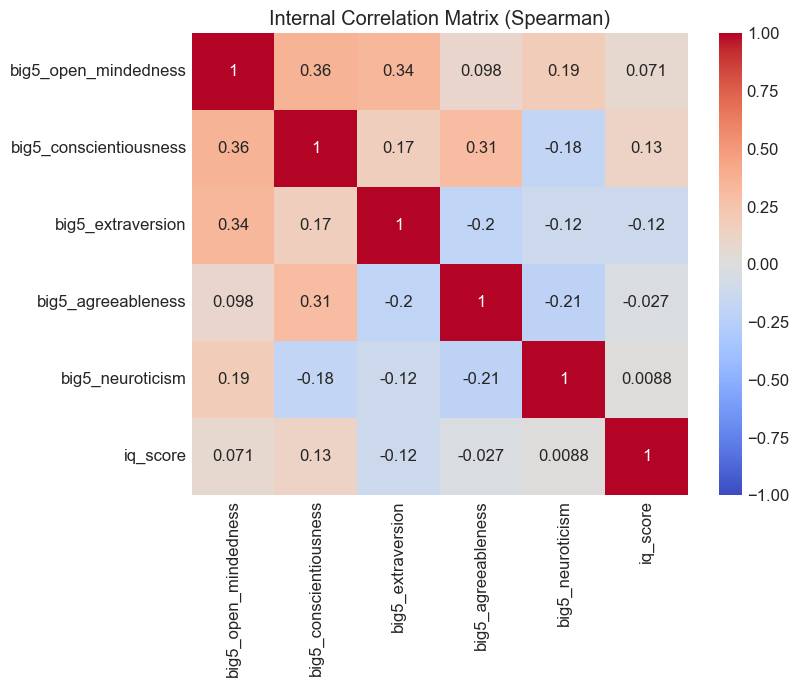


Variance Inflation Factors (VIF > 5 indicates concern):
                 Variable         VIF
0                   const  141.316294
1    big5_open_mindedness    1.468194
2  big5_conscientiousness    1.349282
3       big5_extraversion    1.366464
4      big5_agreeableness    1.254144
5        big5_neuroticism    1.258709
6                iq_score    1.065864


In [2]:
print("--- Descriptive Psychometrics ---")
print(df_part[b5_cols].describe())

corr = df_part[b5_cols].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Internal Correlation Matrix (Spearman)")
plt.show()

# VIF for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(df_part[b5_cols].dropna())
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors (VIF > 5 indicates concern):")
print(vif)


## Section 2: Psychometrics and Accuracy

In [3]:
print("--- Spearman Correlations (FDR Corrected) ---")
res = []

# Added 'overall' condition which uses 'accuracy_plat' (overall accuracy)
conditions = [
    ('ai', 'accuracy_ai_condition'), 
    ('no_ai', 'accuracy_noai_condition'),
    ('overall', 'accuracy_plat')
]

for cond, acc_col in conditions:
    for c in b5_cols:
        r, p = stats.spearmanr(df_part[c], df_part[acc_col], nan_policy='omit')
        res.append({'Condition': cond, 'Trait': c, 'r': r, 'p_raw': p})

res_df = pd.DataFrame(res)
res_df['p_fdr'] = multipletests(res_df['p_raw'], method='fdr_bh')[1]

# Add stars for significance (p < 0.05)
res_df['Sig_raw'] = res_df['p_raw'].apply(lambda x: '*' if x < 0.05 else '')
res_df['Sig_fdr'] = res_df['p_fdr'].apply(lambda x: '*' if x < 0.05 else '')

# Display the table
display(res_df.sort_values(['Condition', 'p_raw']))


print("\n--- GEE Model: Accuracy ~ Psychometrics + Condition ---")
# Added big5_extraversion and big5_agreeableness to the formula
formula = "human_correct_plat_int ~ iq_score + big5_neuroticism + big5_conscientiousness + big5_open_mindedness + big5_extraversion + big5_agreeableness + C(condition)"
m_acc = smf.gee(formula, groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

# Convert GEE results to a DataFrame and add significance stars
gee_res = pd.DataFrame(m_acc.summary().tables[1].data[1:], columns=m_acc.summary().tables[1].data[0])
gee_res.columns = ['Feature', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]']
gee_res['Sig'] = pd.to_numeric(gee_res['P>|z|'], errors='coerce').apply(lambda p: '*' if p < 0.05 else '')

display(gee_res)


--- Spearman Correlations (FDR Corrected) ---


,Condition,Trait,r,p_raw,p_fdr,Sig_raw,Sig_fdr
3,ai,big5_agreeableness,0.243059,0.085681,0.265279,,
4,ai,big5_neuroticism,0.135493,0.343126,0.514689,,
5,ai,iq_score,-0.063018,0.660428,0.792514,,
2,ai,big5_extraversion,0.026876,0.851499,0.952585,,
1,ai,big5_conscientiousness,-0.018103,0.899663,0.952585,,
0,ai,big5_open_mindedness,0.001590,0.991168,0.991168,,
8,no_ai,big5_extraversion,0.313300,0.025180,0.183495,*,
10,no_ai,big5_neuroticism,0.312333,0.025658,0.183495,*,
9,no_ai,big5_agreeableness,-0.271502,0.053953,0.242789,,
11,no_ai,iq_score,-0.237707,0.093024,0.265279,,



--- GEE Model: Accuracy ~ Psychometrics + Condition ---


,Feature,coef,std err,z,P>|z|,[0.025,0.975],Sig
0,Intercept,0.4303,0.609,0.707,0.480,-0.763,1.624,
1,C(condition)[T.no_ai],-0.1530,0.114,-1.348,0.178,-0.376,0.069,
2,iq_score,-0.0364,0.029,-1.254,0.210,-0.093,0.020,
3,big5_neuroticism,0.1854,0.070,2.650,0.008,0.048,0.323,*
4,big5_conscientiousness,-0.0778,0.102,-0.761,0.446,-0.278,0.123,
5,big5_open_mindedness,-0.0261,0.105,-0.248,0.804,-0.233,0.180,
6,big5_extraversion,0.1619,0.098,1.649,0.099,-0.031,0.354,
7,big5_agreeableness,0.0867,0.141,0.617,0.537,-0.189,0.362,


## Section 3: Psychometrics and Reliance Behavior

In [4]:
print("--- Reliance Behavior Predictors ---")
rel_res = []
for c in b5_cols:
    r, p = stats.spearmanr(df_part[c], df_part['over_reliance_rate'], nan_policy='omit')
    rel_res.append({'Trait': c, 'Outcome': 'over_reliance', 'r': r, 'p_raw': p})
    
    r2, p2 = stats.spearmanr(df_part[c], df_part['appropriate_skepticism_rate'], nan_policy='omit')
    rel_res.append({'Trait': c, 'Outcome': 'approp_skepticism', 'r': r2, 'p_raw': p2})

rel_df = pd.DataFrame(rel_res)
rel_df['p_fdr'] = multipletests(rel_df['p_raw'], method='fdr_bh')[1]

# Add stars for significance (p < 0.05)
rel_df['Sig_raw'] = rel_df['p_raw'].apply(lambda x: '*' if x < 0.05 else '')
rel_df['Sig_fdr'] = rel_df['p_fdr'].apply(lambda x: '*' if x < 0.05 else '')

display(rel_df[rel_df['Outcome'] == 'over_reliance'].sort_values('p_fdr'))

print("\n--- GEE Model: Over-Reliance ~ Psychometrics ---")
# Limit to AI condition since over_reliance only happens there
ai_df = df[df['condition'] == 'ai']
formula_rel = "over_reliance_int ~ iq_score + big5_neuroticism"
m_rel = smf.gee(formula_rel, groups=ai_df["participant_id"], data=ai_df, family=sm.families.Binomial()).fit()

# Convert GEE results to a DataFrame and add significance stars
gee_rel_res = pd.DataFrame(m_rel.summary().tables[1].data[1:], columns=m_rel.summary().tables[1].data[0])
gee_rel_res.columns = ['Feature', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]']
gee_rel_res['Sig'] = pd.to_numeric(gee_rel_res['P>|z|'], errors='coerce').apply(lambda p: '*' if p < 0.05 else '')

display(gee_rel_res)

# Directional test for Neuroticism (one-sided)
p_neu = m_rel.pvalues['big5_neuroticism'] / 2 if m_rel.params['big5_neuroticism'] > 0 else 1 - (m_rel.pvalues['big5_neuroticism'] / 2)
print(f"\nOne-sided p-value for Neuroticism predicting higher Over-Reliance: p = {p_neu:.4f}")


--- Reliance Behavior Predictors ---


,Trait,Outcome,r,p_raw,p_fdr,Sig_raw,Sig_fdr
8,big5_neuroticism,over_reliance,-0.389762,0.004696,0.028174,*,*
6,big5_agreeableness,over_reliance,-0.197873,0.163962,0.491887,,
0,big5_open_mindedness,over_reliance,-0.134581,0.346416,0.525738,,
4,big5_extraversion,over_reliance,-0.133458,0.350492,0.525738,,
10,iq_score,over_reliance,0.081832,0.568089,0.681707,,
2,big5_conscientiousness,over_reliance,-0.052328,0.715351,0.715351,,



--- GEE Model: Over-Reliance ~ Psychometrics ---


,Feature,coef,std err,z,P>|z|,[0.025,0.975],Sig
0,Intercept,-1.2632,0.348,-3.626,0.000,-1.946,-0.580,*
1,iq_score,0.0162,0.072,0.227,0.821,-0.124,0.156,
2,big5_neuroticism,-0.4290,0.120,-3.573,0.000,-0.664,-0.194,*



One-sided p-value for Neuroticism predicting higher Over-Reliance: p = 0.9998


## Section 4: Facet-level Analysis

--- Facet-Level Exploratory Analysis ---


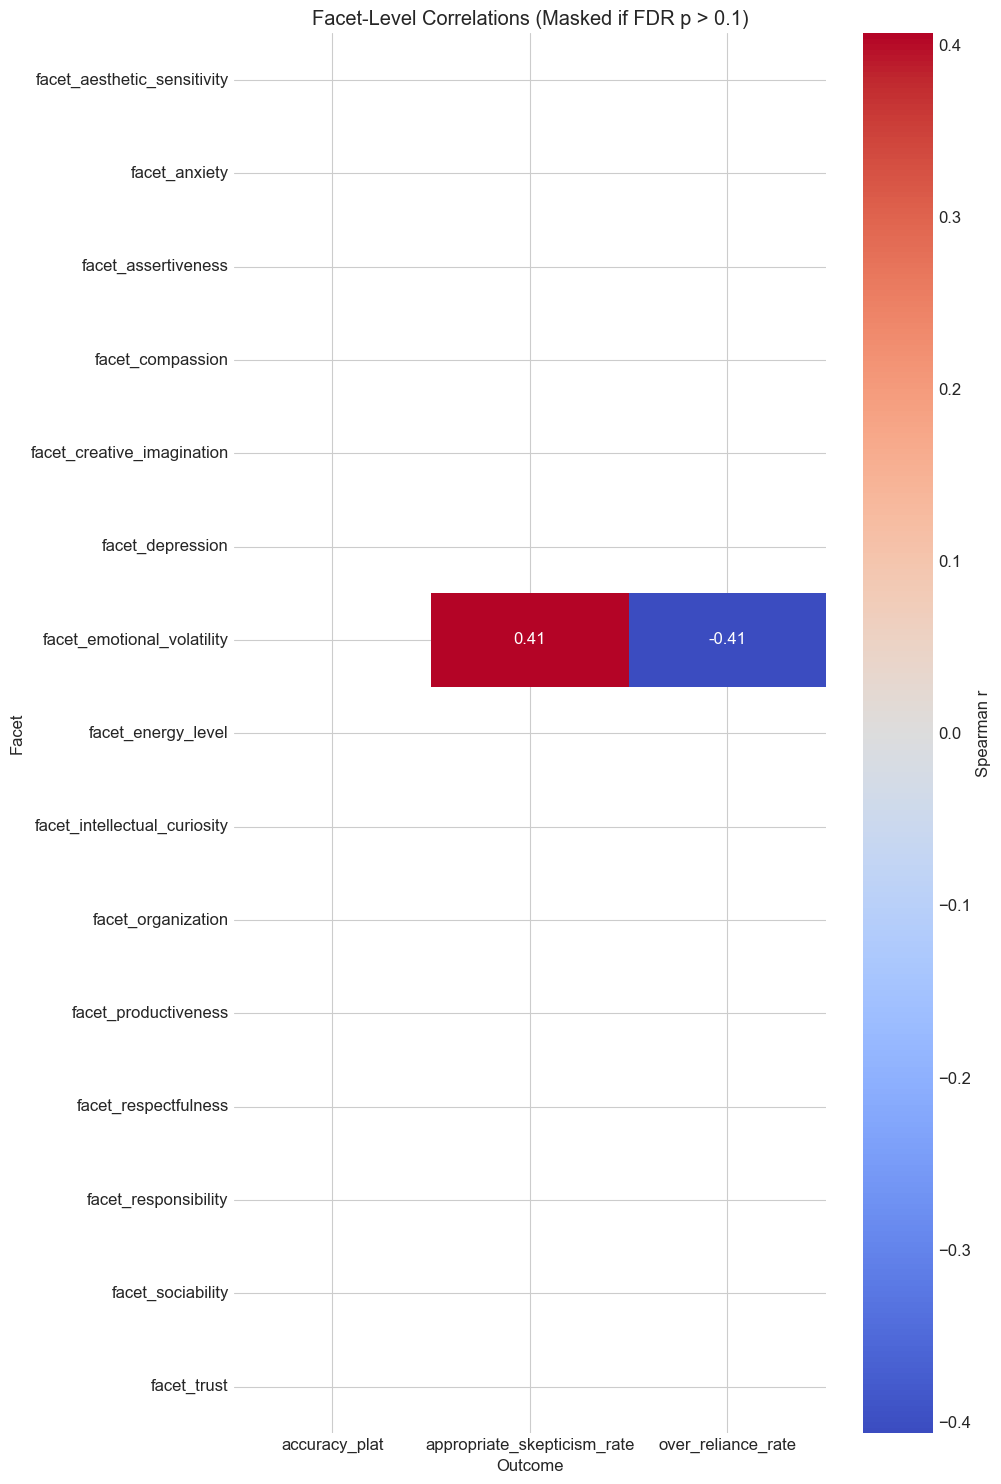

In [5]:
print("--- Facet-Level Exploratory Analysis ---")
if len(facet_cols) == 0:
    print("No facet columns found.")
else:
    f_res = []
    outcomes = ['accuracy_plat', 'over_reliance_rate', 'appropriate_skepticism_rate']
    for out in outcomes:
        for f in facet_cols:
            r, p = stats.spearmanr(df_part[f], df_part[out], nan_policy='omit')
            f_res.append({'Facet': f, 'Outcome': out, 'r': r, 'p_raw': p})
    
    f_df = pd.DataFrame(f_res)
    f_df['p_fdr'] = multipletests(f_df['p_raw'], method='fdr_bh')[1]
    
    # Heatmap of facets vs outcomes (colored by r, but only showing if FDR significant, or masking)
    pivot_r = f_df.pivot(index='Facet', columns='Outcome', values='r')
    pivot_p = f_df.pivot(index='Facet', columns='Outcome', values='p_fdr')
    
    # Mask non-significant correlations
    mask = pivot_p > 0.1 # Using 0.1 for exploratory visibility
    
    plt.figure(figsize=(10, 15))
    sns.heatmap(pivot_r, mask=mask, annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Spearman r'})
    plt.title("Facet-Level Correlations (Masked if FDR p > 0.1)")
    plt.tight_layout()
    plt.show()


## Section 5: Robustness Under GT Switch

In [10]:
print("--- GT Switch Robustness ---")

# 1. Platinum Ground Truth Table
plat_df = pd.DataFrame({
    'Platinum (OR)': np.exp(m_acc.params),
    'Platinum (p)': m_acc.pvalues,
    'Platinum (*)': m_acc.pvalues.apply(lambda p: '*' if p < 0.05 else '')
})
print("\n[ Platinum Ground Truth ]")
display(plat_df.round(3))


# 2. Original Ground Truth Table
m_acc_orig = smf.gee("human_correct_orig_int ~ iq_score + big5_neuroticism + big5_conscientiousness + big5_open_mindedness + big5_extraversion + big5_agreeableness + C(condition)", 
                     groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

orig_df = pd.DataFrame({
    'Original (OR)': np.exp(m_acc_orig.params),
    'Original (p)': m_acc_orig.pvalues,
    'Original (*)': m_acc_orig.pvalues.apply(lambda p: '*' if p < 0.05 else '')
})
print("\n[ Original Ground Truth ]")
display(orig_df.round(3))


--- GT Switch Robustness ---

[ Platinum Ground Truth ]


,Platinum (OR),Platinum (p),Platinum (*)
Intercept,1.538,0.480,
C(condition)[T.no_ai],0.858,0.178,
iq_score,0.964,0.210,
big5_neuroticism,1.204,0.008,*
big5_conscientiousness,0.925,0.446,
big5_open_mindedness,0.974,0.804,
big5_extraversion,1.176,0.099,
big5_agreeableness,1.091,0.537,



[ Original Ground Truth ]


,Original (OR),Original (p),Original (*)
Intercept,3.570,0.001,*
C(condition)[T.no_ai],0.880,0.087,
iq_score,1.001,0.948,
big5_neuroticism,1.035,0.482,
big5_conscientiousness,1.171,0.003,*
big5_open_mindedness,1.000,0.996,
big5_extraversion,0.878,0.045,*
big5_agreeableness,0.937,0.359,
